In [105]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import nlopt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


from scipy.optimize import brentq


%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *
from src.nominal_speed_func import *
from src.cooperation_surplus import *
from src.macroscopic_data import *

#feet を　メートルに変換する係数 1feet=0.3048m
FT_TO_M = 0.3048

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### データの読み込み・フィルタリング・名目速度関数の推定・マクロ密度の計算

In [106]:
# データの読み込みと前処理
df = load_trajectory_data()

#　フリッカリングノイズを除去
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=10)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=10) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

(4566387, 19)

--フリッカリング除去--
補正されたブロック数: 671
行数: 4,566,387

--フリッカリング除去--
補正されたブロック数: 142
行数: 4,566,387

--ペアIDを付与--
総行数: 4,566,387
追従ペア数: 13,827

--モードID別を付与--
総行数: 4,566,387
追従ペア数: 13,827
mode_id
1.0    12337
2.0      438
3.0      549
4.0       42
5.0      461
dtype: int64

--追従していない軌跡データを削除--
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,359,245
除外された行数: 207,142
ペア数: 13,827

--車線フィルタ(2,3,4レーンを残す)--
フィルタ前: 4,359,245行
フィルタ後: 2,338,830行
除外された行数: 2,020,415行
追従ペア数: 5,780

車線の分布:
Lane_ID
2.0    800339
3.0    689350
4.0    849141
Name: count, dtype: int64

--車種フィルタ(1,2,3,4の追従モードを残す)--
フィルタ前のペア数: 5,780
フィルタ後のペア数: 5,666
除外されたペア数: 114
フィルタ後行数: 2,335,438行

モードID別ペア数:
mode_id
1.0    5067
2.0     237
3.0     326
4.0      36
dtype: int64

--追従時間フィルタ--
フィルタ前のペア数: 5,666
フィルタ後のペア数: 1,570
除外されたペア数: 4,096
フィルタ前の行数: 2,335,438
フィルタ後の行数: 1,487,854

--カットオフウィンドウ--
カットオフ前の行数: 1,487,854
カットオフ後の行数: 1,173,854
除外された行数: 314,000
カットオフ前のペア数: 1,570
カットオフ後のペア数: 1,570

--加速度フィルタ--
フィルタ前の行数: 1,173,854
フィルタ後の行数: 881,448
除外された行数: 29

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,17.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,17.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,17.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,17.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,17.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487747,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,20091.0,2.0,2,1.0,C-C
1487748,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,20091.0,2.0,2,1.0,C-C
1487749,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,20091.0,2.0,2,1.0,C-C
1487750,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,20091.0,2.0,2,1.0,C-C


In [107]:
df_final['mode_id'].value_counts().sort_index()

mode_id
1.0    815231
2.0     36231
3.0     26210
4.0      3776
Name: count, dtype: int64

In [4]:
#名目速度関数の推定
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#c-cペア
#ほとんど論文値を与えた場合(theta2だけをフィッティング)
results_cc_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=1,
    lower_bounds=[12.76, 118.36, 12.67, 4.99, 0.001],
    upper_bounds=[12.77, 118.37, 12.68, 5.00, 100.0], 
    init_params = [12.762, 118.367, 12.676, 4.995, 0.5]
)

#c-tペア
results_ct_strong_constraint = fit_nominal_speed_logistic(
    df_mdensity, mode_id=2,
    lower_bounds=[10.665, 109.222, 14.119, 2.160, 0.001],
    upper_bounds=[10.675, 109.232, 14.129, 2.170, 100.0], 
    init_params = [10.670, 109.227, 14.124, 2.165, 0.5]
)


#ほとんど論文値を与えた場合(rhocだけをフィッティング)
#t-tペア
results_tt_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=4,
    lower_bounds = [68.473, 1.000],
    upper_bounds = [68.483, 100.000],
    init_params = [68.478, 50.000]
)

#t-cペア
results_tc_strong_constraint = fit_nominal_speed_underwood(
    df_mdensity, mode_id=3,
    lower_bounds = [96.717, 1.000],
    upper_bounds = [96.727, 100.000],
    init_params = [96.722, 50.000]
)

results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
            'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}
results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

# 結果のプロット
# plot_model_logistic(df_mdensity, 1,results_cc_paper_km,result_cc_strong_constraint,"C-C","Paper","speed target (strong constraint)")
# plot_model_logistic(df_mdensity, 2,results_ct_paper_km,result_ct_strong_constraint,"C-T","Paper","speed target (strong constraint)")

# plot_model_underwood(df_mdensity, 4,results_tt_paper_km,result_tt_strong_constraint,"T-T","Paper","speed target (strong constraint)")
# plot_model_underwood(df_mdensity, 3,results_tc_paper_km,result_tc_strong_constraint,"T-C","Paper","speed target (strong constraint)")


#スケーリングパラメータの計算
results_a2 = fit_scaling_parameter_logistic(df_mdensity, mode_id=2, nominal_params=results_cc_strong_constraint)
results_b1 = fit_scaling_parameter_underwood(df_mdensity, mode_id=3, nominal_params=results_tt_strong_constraint)


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:163: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / ((1 + exp_term) ** theta2)


KeyboardInterrupt: 

In [108]:
#マクロ密度の計算
df_macro_data = compute_macroscopic_data(df_final, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)
df_macro_data.head()

区間長: 472.7 m, 車線数: 3

--マクロ密度・平均速度を計算--


,time_period,Global_Time,v_Class,n_vehicles,speed_kmh,density_veh_km,flow_veh_h
0,1,1113433150600,2,1,8.229600,0.705166,5.803232
1,1,1113433151100,2,1,8.229600,0.705166,5.803232
2,1,1113433152100,2,1,10.446106,0.705166,7.366236
3,1,1113433153100,2,1,15.965424,0.705166,11.258270
4,1,1113433153600,2,1,15.910560,0.705166,11.219581


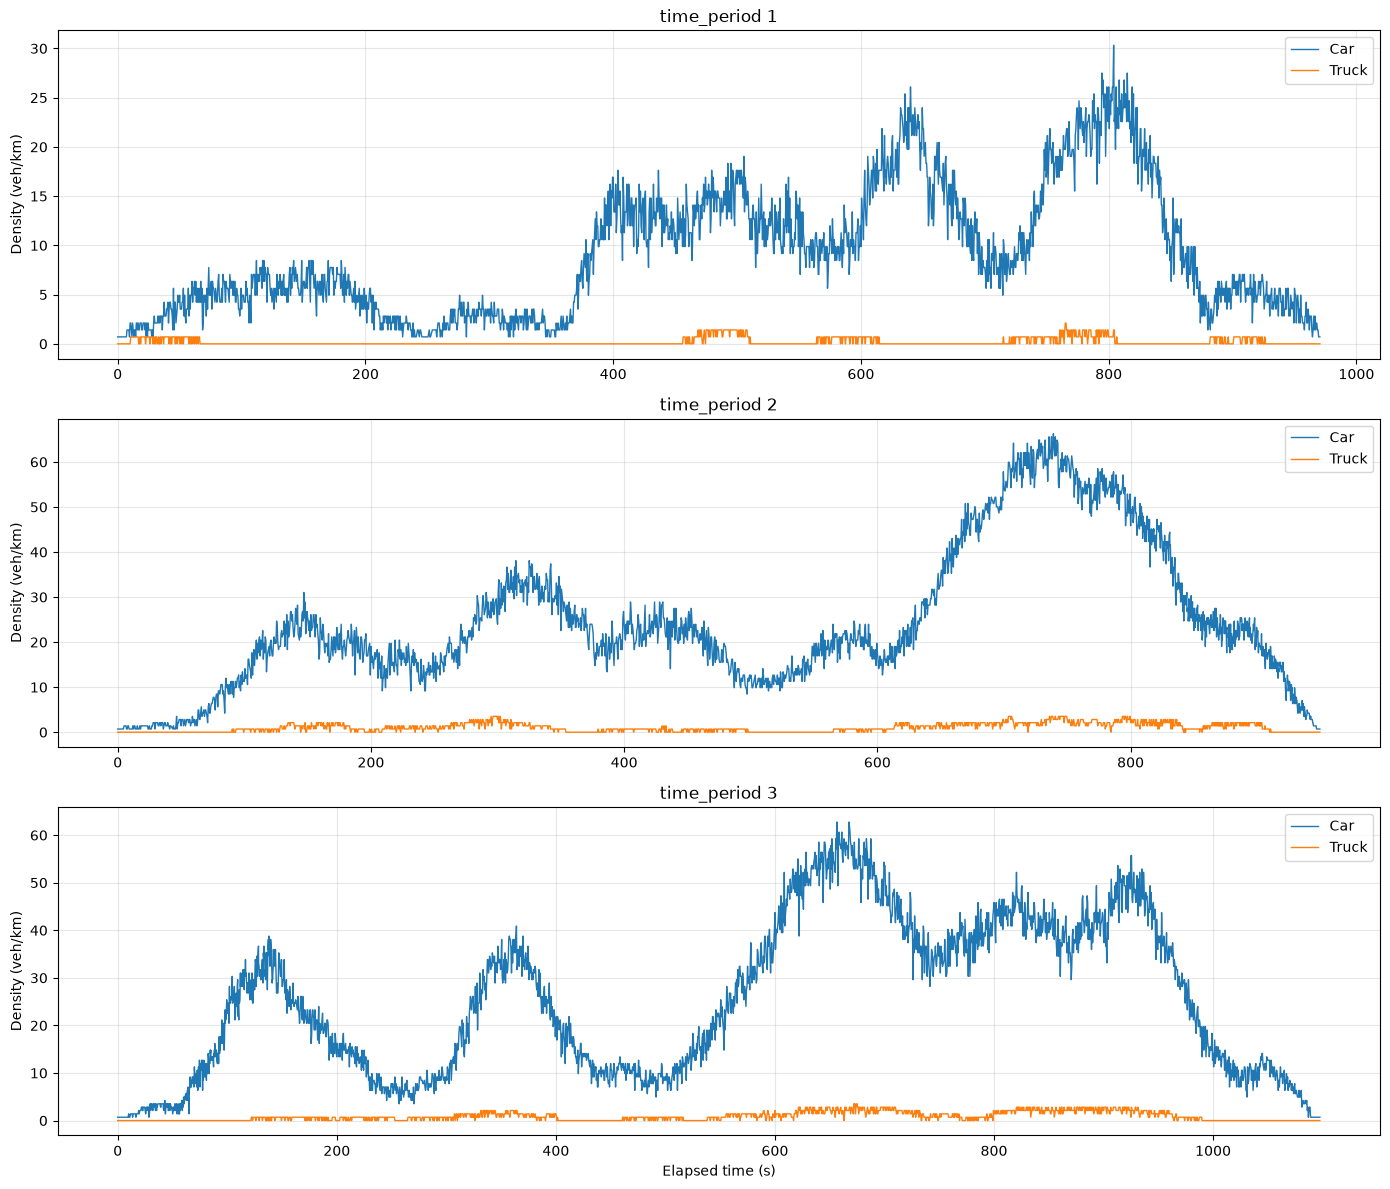

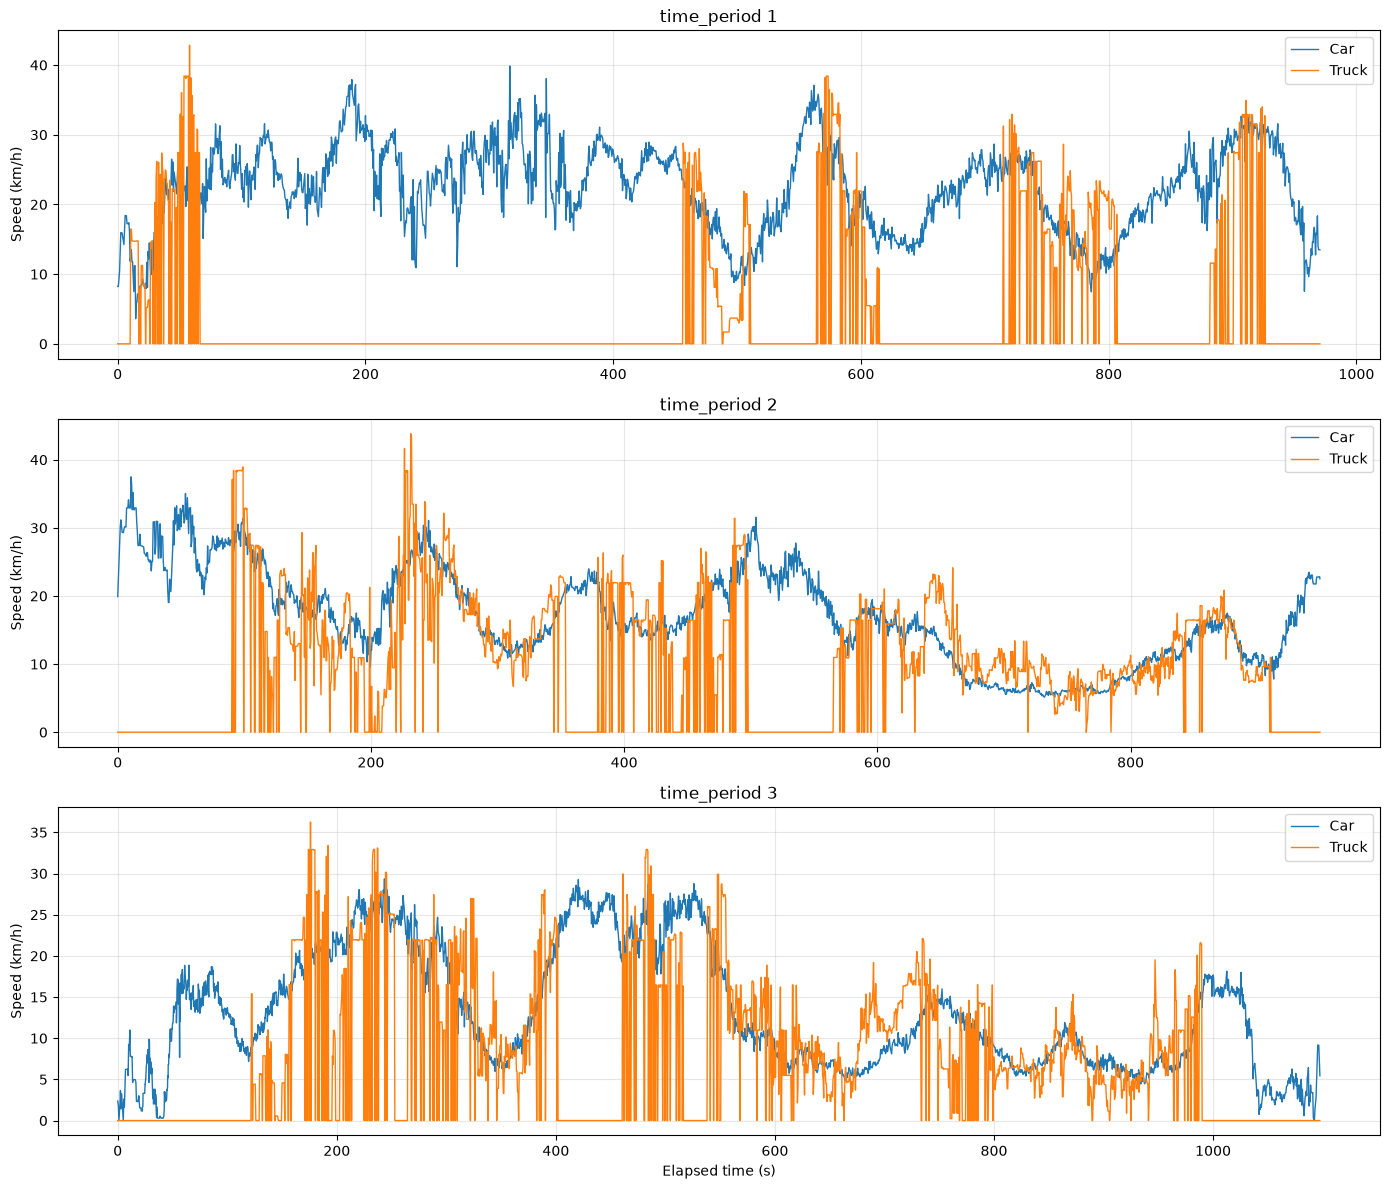

In [109]:
#マクロデータの時間推移
plot_macro_timeseries(df_macro_data, 'density_veh_km', 'Density (veh/km)')
plot_macro_timeseries(df_macro_data, 'speed_kmh', 'Speed (km/h)')

In [110]:
# ============================================================
# キャッシュ済みテストパラメータ
# (2026-09-02の実行結果。カーネル再起動のたびにISRESを再実行しなくて済むように、
#  実際の関数の戻り値と同じ形式でハードコードしたもの)
# ============================================================
#名目速度関数の推定
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_mdensity = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

results_cc_strong_constraint = {
    'mode_id': 1, 'ub': 12.760, 'uf': 118.369, 'rhoc': 12.676,
    'theta1': 4.999, 'theta2': 0.343, 'test_mae': 7.055
}

results_ct_strong_constraint = {
    'mode_id': 2, 'ub': 10.674, 'uf': 109.230, 'rhoc': 14.120,
    'theta1': 2.167, 'theta2': 0.425, 'test_mae': 6.564
}

results_tt_strong_constraint = {
    'mode_id': 4, 'uf': 68.473, 'rhoc': 18.542, 'test_mae': 5.862
}

results_tc_strong_constraint = {
    'mode_id': 3, 'uf': 96.717, 'rhoc': 26.806, 'test_mae': 6.717
}

results_a2 = {
    'mode_id': 2, 'scaling_param': 0.4687, 'test_mae': 6.789
}

results_b1 = {
    'mode_id': 3, 'scaling_param': 1.8331, 'test_mae': 6.106
}

#論文値　これで推測すれば、論文の結果が再現できるはず
results_cc_paper_km =  {'mode_id': 1, 'ub': 12.762, 'uf': 118.367, 'rhoc': 12.676,
            'theta1': 4.995, 'theta2': 0.2309, 'test_mae': 6.73}
results_ct_paper_km =  {'mode_id': 2, 'ub': 10.670, 'uf': 109.227, 'rhoc': 14.124,
            'theta1': 2.165, 'theta2': 0.2673, 'test_mae': 7.55}

results_tt_paper_km =  {'mode_id': 4, 'uf': 68.478,'rhoc': 25.936, 'test_mae': 3.94}
results_tc_paper_km =  {'mode_id': 3, 'uf': 96.722,'rhoc': 49.393, 'test_mae': 12.57}

results_a2_paper_km = {
    'mode_id': 2, 'scaling_param': 0.4528, 'test_mae': 7.37
}

results_b1_paper_km = {
    'mode_id': 3, 'scaling_param': 2.5996, 'test_mae': 10.40
}


--閾値以下の車頭距離データを除外--
spacing <= 4.5m (14.76ft) の行を除外: 881,448 -> 878,719 (除外 2,729行)

--ミクロ密度を計算--


### 1-pipe速度(u*)の計算

In [111]:
# 論文Eq(7)の残差を求める関数（その時のu*がどれくらい式(7)の等式を満たしているか）
# # ※ underwood_density_speed, logistic_density_speed は
#    nominal_speed_func.py に定義済みのものをそのまま使う
# a1=1（cc追従）、 b2=1（tt追従）
def _eq7_residual(u, rho1, rho2, car_params, truck_params, a2, b1):
    rho_tot = rho1 + rho2
    #その時の入力値がどれくらい関数を満たしているかを返す
    #u*の時のu1,u2の逆関数を計算　u1_invは密度
    u1_inv = logistic_density_speed(
        u, car_params['ub'], car_params['uf'], car_params['rhoc'],
        car_params['theta1'], car_params['theta2']
    )
    u2_inv = underwood_density_speed(u, truck_params['uf'], truck_params['rhoc'])

    #sigma_j=1^j=2を崩して書いた形
    term1 = (rho1 / u1_inv) * (rho1 / 1.0 + rho2 / a2)
    term2 = (rho2 / u2_inv) * (rho1 / b1 + rho2 / 1.0)

    #eq(7)の左辺と右辺の差を返す。0に近いほど式(7)を満たす
    return (term1 + term2) / rho_tot - 1.0

#brent法でu*を求める関数
def solve_1pipe_speed(rho1, rho2, car_params, truck_params, a2, b1,
                       u_lower=None, u_upper=None, margin=1e-3):
    """
    論文Eq(7)をBrent法（scipy.optimize.brentq）で解き、1-pipe速度u*を求める。

    rho1, rho2: マクロ密度（veh/km）。クラス1=車、クラス2=トラック
    car_params: fit_nominal_speed_logistic の戻り値（C-C）
    truck_params: fit_nominal_speed_underwood の戻り値（T-T）
    a2: fit_scaling_parameter_logistic の戻り値の'scaling_param'
    b1: fit_scaling_parameter_underwood の戻り値の'scaling_param'
    u_lower, u_upper: 探索区間。省略時は車のub・両クラスのufから自動決定
    """
    if rho1 + rho2 <= 0:
        return np.nan  # 車もトラックもいないスナップショットは対象外

    if u_lower is None or u_upper is None:
        lowers, uppers = [], []
        if rho1 > 0:
            #lowers.append(car_params['ub'] + margin)
            lowers.append(margin)
            # 車の"uf"は密度→-∞の極限値で、密度0でも到達できない。
            # 密度0での実際の到達可能な最高速度 f(0) を上限にする。
            car_speed_at_zero = logistic_speed_density(
                0.0, car_params['ub'], car_params['uf'], car_params['rhoc'],
                car_params['theta1'], car_params['theta2']
            )
            uppers.append(car_speed_at_zero - margin)
        if rho2 > 0:
            lowers.append(margin)
            uppers.append(truck_params['uf'] - margin)  # Underwoodはg(0)=ufなので問題なし
        if u_lower is None:
            u_lower = max(lowers)
        if u_upper is None:
            u_upper = min(uppers)

    #uだけを引数に持つ関数を新たに作る
    f = lambda u: _eq7_residual(u, rho1, rho2, car_params, truck_params, a2, b1)
    #ブレント法でf(u)=0となるuを求める
    return brentq(f, u_lower, u_upper)


# マクロ密度のスナップショット表全体(rho1,rho2の組み合わせ)に対して1-pipe速度を計算
def compute_1pipe_speed_for_snapshots(df_macro, car_params, truck_params, a2, b1,
                                        car_class=2, truck_class=3):
    """
    df_macro: compute_macroscopic_data の返り値
              （time_period, Global_Time, v_Class, density_veh_km, ... を含む）
    """
    #縦持ちのデータを横並びに変換　
    pivot = df_macro.pivot_table(
        index=['time_period', 'Global_Time'],#timeperiodとGlobal_Timeが同じなら同じ行にまとめる
        columns='v_Class',#クラスを新たな列名にする
        values='density_veh_km'#その時の密度を入れる
    ).rename(columns={car_class: 'rho1', truck_class: 'rho2'})#列名をわかりやすくする

    #片方のクラスがないスナップショットはnanでは困るので0として扱う
    pivot[['rho1', 'rho2']] = pivot[['rho1', 'rho2']].fillna(0.0)
    #インデックスを普通の行に戻す
    pivot = pivot.reset_index()

    #1行ずつ1-pipe速度を計算する関数
    #もし、下限と上限の範囲で0をはさめず、解が存在しない場合(ブレント法のエラーになる場合)も止まらないようにnanを返す
    def _solve_row(row):
        try:
            return solve_1pipe_speed(row['rho1'], row['rho2'], car_params, truck_params, a2, b1)
        except ValueError:
            return np.nan

    pivot['rho_tot'] = pivot['rho1'] + pivot['rho2']
    pivot['u_1pipe'] = pivot.apply(_solve_row, axis=1)#すべての行に適応　結果を新しい列として追加

    print(f"1-pipe速度を計算: {len(pivot):,}スナップショット中、"
          f"{pivot['u_1pipe'].notna().sum():,}件で解を取得")

    return pivot

In [31]:
def _bin_and_aggregate_1pipe(df, rho1_col, rho2_col, bin_width1, bin_width2,
                               max_rho1, max_rho2, min_count, value_col='u_1pipe',
                               min_rho1=0.6, min_rho2=0.6):
    """rho1_col, rho2_colの密度をビンに区切り、各ビンのvalue_colの平均をまとめる共通処理。"""
    bins1 = np.arange(min_rho1, max_rho1 + bin_width1, bin_width1)
    bins2 = np.arange(min_rho2, max_rho2 + bin_width2, bin_width2)

    df = df.copy()
    df['_bin1'] = pd.cut(df[rho1_col], bins=bins1, include_lowest=True)
    df['_bin2'] = pd.cut(df[rho2_col], bins=bins2, include_lowest=True)

    cats1 = df['_bin1'].cat.categories
    cats2 = df['_bin2'].cat.categories

    grid = df.groupby(['_bin2', '_bin1'], observed=True).agg(
        mean_val=(value_col, 'mean'), count=(value_col, 'size')
    ).reset_index()

    heat = grid.pivot(index='_bin2', columns='_bin1', values='mean_val').reindex(index=cats2, columns=cats1)
    counts = grid.pivot(index='_bin2', columns='_bin1', values='count').reindex(index=cats2, columns=cats1)
    heat = heat.where(counts >= min_count)

    return bins1, bins2, heat


def plot_1pipe_speed_heatmap(df_1pipe, bin_width1=1.0, bin_width2=1.0,
                               max_rho1=None, max_rho2=None, min_count=3,
                               min_rho1=0.6, min_rho2=0.6):
    """
    1-pipe速度のヒートマップを、km単位版とmile単位版(論文の単位)を横並びで表示する。

    min_rho1, min_rho2: 密度の下限(km単位)。論文Fig.11がρ=1未満を表示していないのに
    合わせてデフォルトを1にしている。mile版はmin_rho1*KM_TO_MILEとして換算される
    (他のbin_width1・max_rho1と同じ扱い)。
    """
    df = df_1pipe.dropna(subset=['u_1pipe']).copy()

    if max_rho1 is None:
        max_rho1 = df['rho1'].max()
    if max_rho2 is None:
        max_rho2 = df['rho2'].max()

    # --- km版 ---
    bins1_km, bins2_km, heat_kmh = _bin_and_aggregate_1pipe(
        df, 'rho1', 'rho2', bin_width1, bin_width2, max_rho1, max_rho2, min_count,
        min_rho1=min_rho1, min_rho2=min_rho2
    )

    # --- mile版：rho1, rho2をmileに変換してから、mile換算のビン幅・下限で独立に再分割 ---
    df['rho1_mile'] = df['rho1'] * KM_TO_MILE
    df['rho2_mile'] = df['rho2'] * KM_TO_MILE
    bin_width1_mile = bin_width1 * KM_TO_MILE
    bin_width2_mile = bin_width2 * KM_TO_MILE
    max_rho1_mile = max_rho1 * KM_TO_MILE
    max_rho2_mile = max_rho2 * KM_TO_MILE
    min_rho1_mile = min_rho1 * KM_TO_MILE
    min_rho2_mile = min_rho2 * KM_TO_MILE

    bins1_mile, bins2_mile, heat_kmh_in_mile_bins = _bin_and_aggregate_1pipe(
        df, 'rho1_mile', 'rho2_mile', bin_width1_mile, bin_width2_mile,
        max_rho1_mile, max_rho2_mile, min_count,
        min_rho1=min_rho1_mile, min_rho2=min_rho2_mile
    )
    heat_mph = heat_kmh_in_mile_bins / KM_TO_MILE

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    mesh0 = axes[0].pcolormesh(bins1_km, bins2_km, heat_kmh.values, cmap='plasma', vmin=0, shading='flat')
    fig.colorbar(mesh0, ax=axes[0], label='1-pipe speed (km/h)')
    axes[0].set_xlabel('Density class 1 - Car (veh/km)')
    axes[0].set_ylabel('Density class 2 - Truck (veh/km)')
    axes[0].set_title('1-pipe Speed Heatmap (km)')

    mesh1 = axes[1].pcolormesh(bins1_mile, bins2_mile, heat_mph.values, cmap='plasma', vmin=0, shading='flat')
    fig.colorbar(mesh1, ax=axes[1], label='1-pipe speed (mph)')
    axes[1].set_xlabel('Density class 1 - Car (veh/mile)')
    axes[1].set_ylabel('Density class 2 - Truck (veh/mile)')
    axes[1].set_title('1-pipe Speed Heatmap (mile, paper units)')

    plt.tight_layout()
    plt.show()

    return heat_kmh, heat_mph

区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得


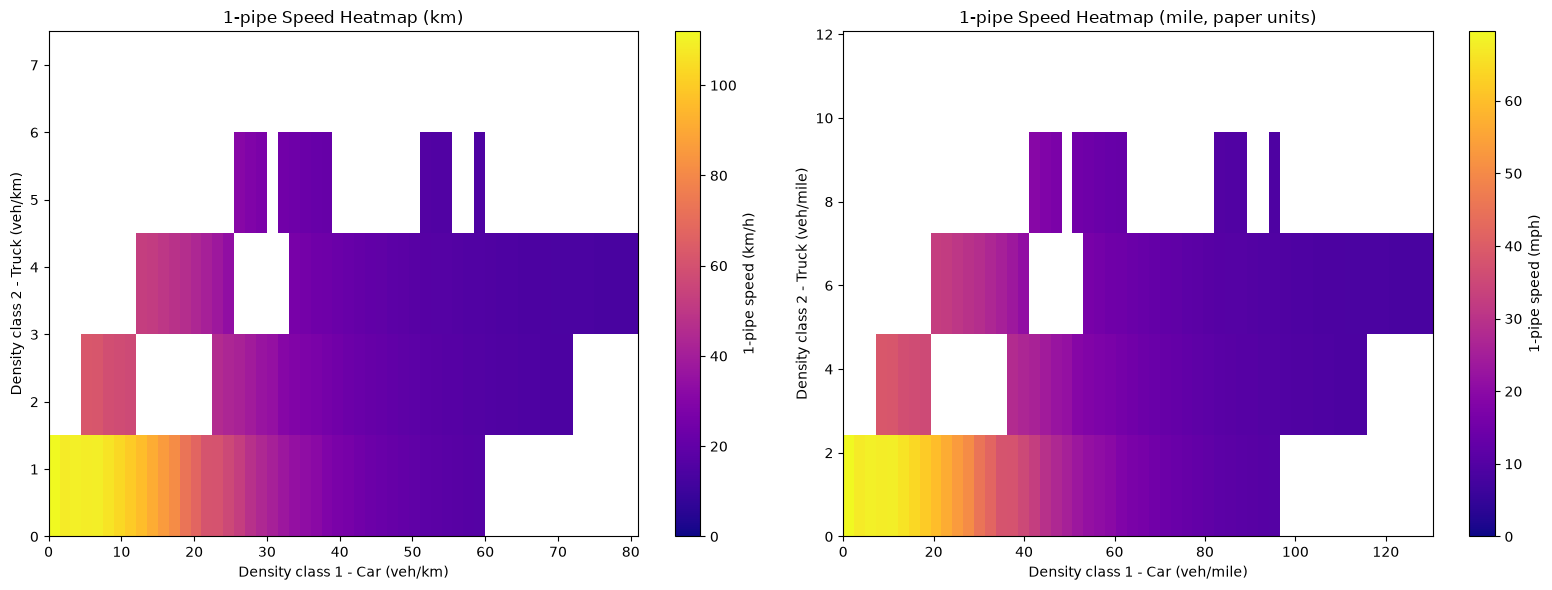

(               (-0.001, 1.5]  (1.5, 3.0]  (3.0, 4.5]  (4.5, 6.0]  (6.0, 7.5]  \
 (-0.001, 1.5]     111.941182  108.389075  109.747686  108.538720  109.103267   
 (1.5, 3.0]               NaN         NaN         NaN   62.470125   62.076508   
 (3.0, 4.5]               NaN         NaN         NaN         NaN         NaN   
 (4.5, 6.0]               NaN         NaN         NaN         NaN         NaN   
 (6.0, 7.5]               NaN         NaN         NaN         NaN         NaN   
 
                (7.5, 9.0]  (9.0, 10.5]  (10.5, 12.0]  (12.0, 13.5]  \
 (-0.001, 1.5]  106.482918   103.394279    100.109739     96.104779   
 (1.5, 3.0]      58.806754    58.120892     57.037574           NaN   
 (3.0, 4.5]            NaN          NaN           NaN     52.835982   
 (4.5, 6.0]            NaN          NaN           NaN           NaN   
 (6.0, 7.5]            NaN          NaN           NaN           NaN   
 
                (13.5, 15.0]  ...  (66.0, 67.5]  (67.5, 69.0]  (69.0, 70.5]  \
 (-0.

In [112]:
#プロット
#macro_dataをdf_final(フィルタリング処理後データ)を用いて行うと、圧倒的に密度不足
#しかし、論文ではprocessed datasetと書かれており、処理後データセットとも読める
df_macro_data = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5 ,L_m=None)
df_macro_data.head()
df_1pipe_full_data = compute_1pipe_speed_for_snapshots(
    df_macro_data,
    car_params=results_cc_strong_constraint,
    truck_params=results_tt_strong_constraint,
    a2=results_a2['scaling_param'],
    b1=results_b1['scaling_param'],
)
plot_1pipe_speed_heatmap(df_1pipe_full_data, bin_width1=1.5, bin_width2=1.5,max_rho1=80, max_rho2=7,min_count=3)

区間長: 472.7 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,561スナップショット中、6,561件で解を取得


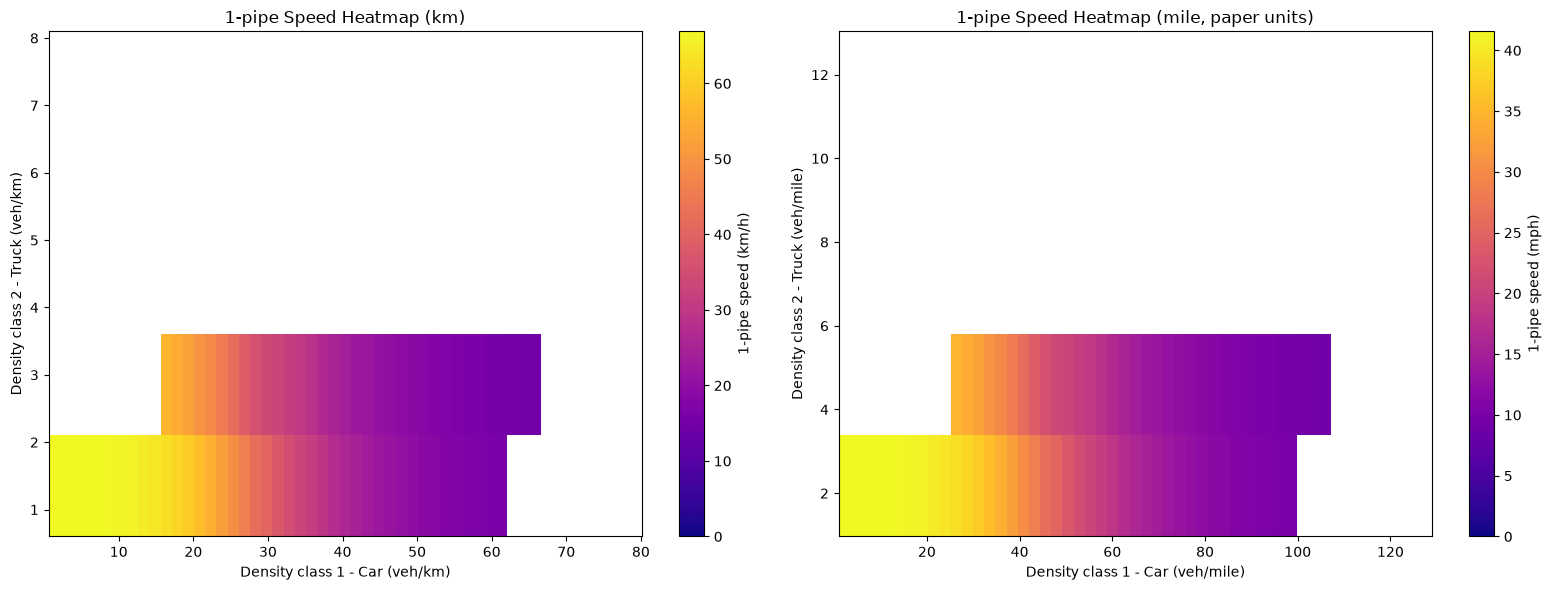

(              (0.599, 2.1]  (2.1, 3.6]  (3.6, 5.1]  (5.1, 6.6]  (6.6, 8.1]  \
 (0.599, 2.1]     66.749771   66.900139   66.879755   66.793707   66.670927   
 (2.1, 3.6]             NaN         NaN         NaN         NaN         NaN   
 (3.6, 5.1]             NaN         NaN         NaN         NaN         NaN   
 (5.1, 6.6]             NaN         NaN         NaN         NaN         NaN   
 (6.6, 8.1]             NaN         NaN         NaN         NaN         NaN   
 
               (8.1, 9.6]  (9.6, 11.1]  (11.1, 12.6]  (12.6, 14.1]  \
 (0.599, 2.1]   66.492779    66.161503     65.785081     64.755006   
 (2.1, 3.6]           NaN          NaN           NaN           NaN   
 (3.6, 5.1]           NaN          NaN           NaN           NaN   
 (5.1, 6.6]           NaN          NaN           NaN           NaN   
 (6.6, 8.1]           NaN          NaN           NaN           NaN   
 
               (14.1, 15.6]  ...  (65.1, 66.6]  (66.6, 68.1]  (68.1, 69.6]  \
 (0.599, 2.1]     63.908

In [40]:
#プロット
df_macro_data = compute_macroscopic_data(df_final, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5 ,L_m=None)
df_macro_data.head()
df_1pipe_filtereddata = compute_1pipe_speed_for_snapshots(
    df_macro_data,
    car_params=results_cc_strong_constraint,
    truck_params=results_tt_strong_constraint,
    a2=results_a2_paper_km['scaling_param'],
    b1=results_b1_paper_km['scaling_param'],
)
plot_1pipe_speed_heatmap(df_1pipe_filtereddata, bin_width1=1.5, bin_width2=1.5,max_rho1=80, max_rho2=7,min_count=3)

In [ ]:
failed = df_1pipe_full_data[df_1pipe_full_data['u_1pipe'].isna()]
print("解けなかった件数の内訳:")
print("  両方0だった:", ((failed['rho1'] == 0) & (failed['rho2'] == 0)).sum())
print("  片方以上0でない(brentq失敗と思われる):", (~((failed['rho1'] == 0) & (failed['rho2'] == 0))).sum())

解けなかった件数の内訳:
  両方0だった: 0
  片方以上0でない(brentq失敗と思われる): 0


In [ ]:
sample = df_1pipe_full_data[df_1pipe_full_data['u_1pipe'].isna() & (df_1pipe_full_data['rho2'] == 0)].head(5)

u_lower = results_cc_strong_constraint['ub'] + 1e-3
u_upper = min(results_cc_strong_constraint['uf'], results_tt_strong_constraint['uf']) - 1e-3

for _, row in sample.iterrows():
    r_lower = _eq7_residual(u_lower, row['rho1'], row['rho2'],
                             results_cc_strong_constraint, results_tt_strong_constraint,
                             results_a2['scaling_param'], results_b1['scaling_param'])
    r_upper = _eq7_residual(u_upper, row['rho1'], row['rho2'],
                             results_cc_strong_constraint, results_tt_strong_constraint,
                             results_a2['scaling_param'], results_b1['scaling_param'])
    print(f"rho1={row['rho1']:.3f}, rho2={row['rho2']:.3f} -> residual(u_lower)={r_lower}, residual(u_upper)={r_upper}")

In [35]:
rho1, rho2 = 60.0, 1.0
u_lower = results_cc_paper_km['ub'] + 1e-3
u_upper = results_tt_paper_km['uf'] - 1e-3

for u in np.linspace(u_lower, u_upper, 20):
    r = _eq7_residual(u, rho1, rho2, results_cc_paper_km, results_tt_paper_km, 0.4528, 2.5996)
    print(f"u={u:7.3f} -> residual={r:10.4f}")

u= 12.763 -> residual=   -0.7582
u= 15.695 -> residual=   -0.3113
u= 18.628 -> residual=   -0.1747
u= 21.560 -> residual=   -0.0658
u= 24.492 -> residual=    0.0310
u= 27.425 -> residual=    0.1214
u= 30.357 -> residual=    0.2082
u= 33.289 -> residual=    0.2931
u= 36.222 -> residual=    0.3772
u= 39.154 -> residual=    0.4615
u= 42.086 -> residual=    0.5468
u= 45.018 -> residual=    0.6338
u= 47.951 -> residual=    0.7234
u= 50.883 -> residual=    0.8168
u= 53.815 -> residual=    0.9156
u= 56.748 -> residual=    1.0229
u= 59.680 -> residual=    1.1452
u= 62.612 -> residual=    1.3006
u= 65.545 -> residual=    1.5788
u= 68.477 -> residual= 1043.6064


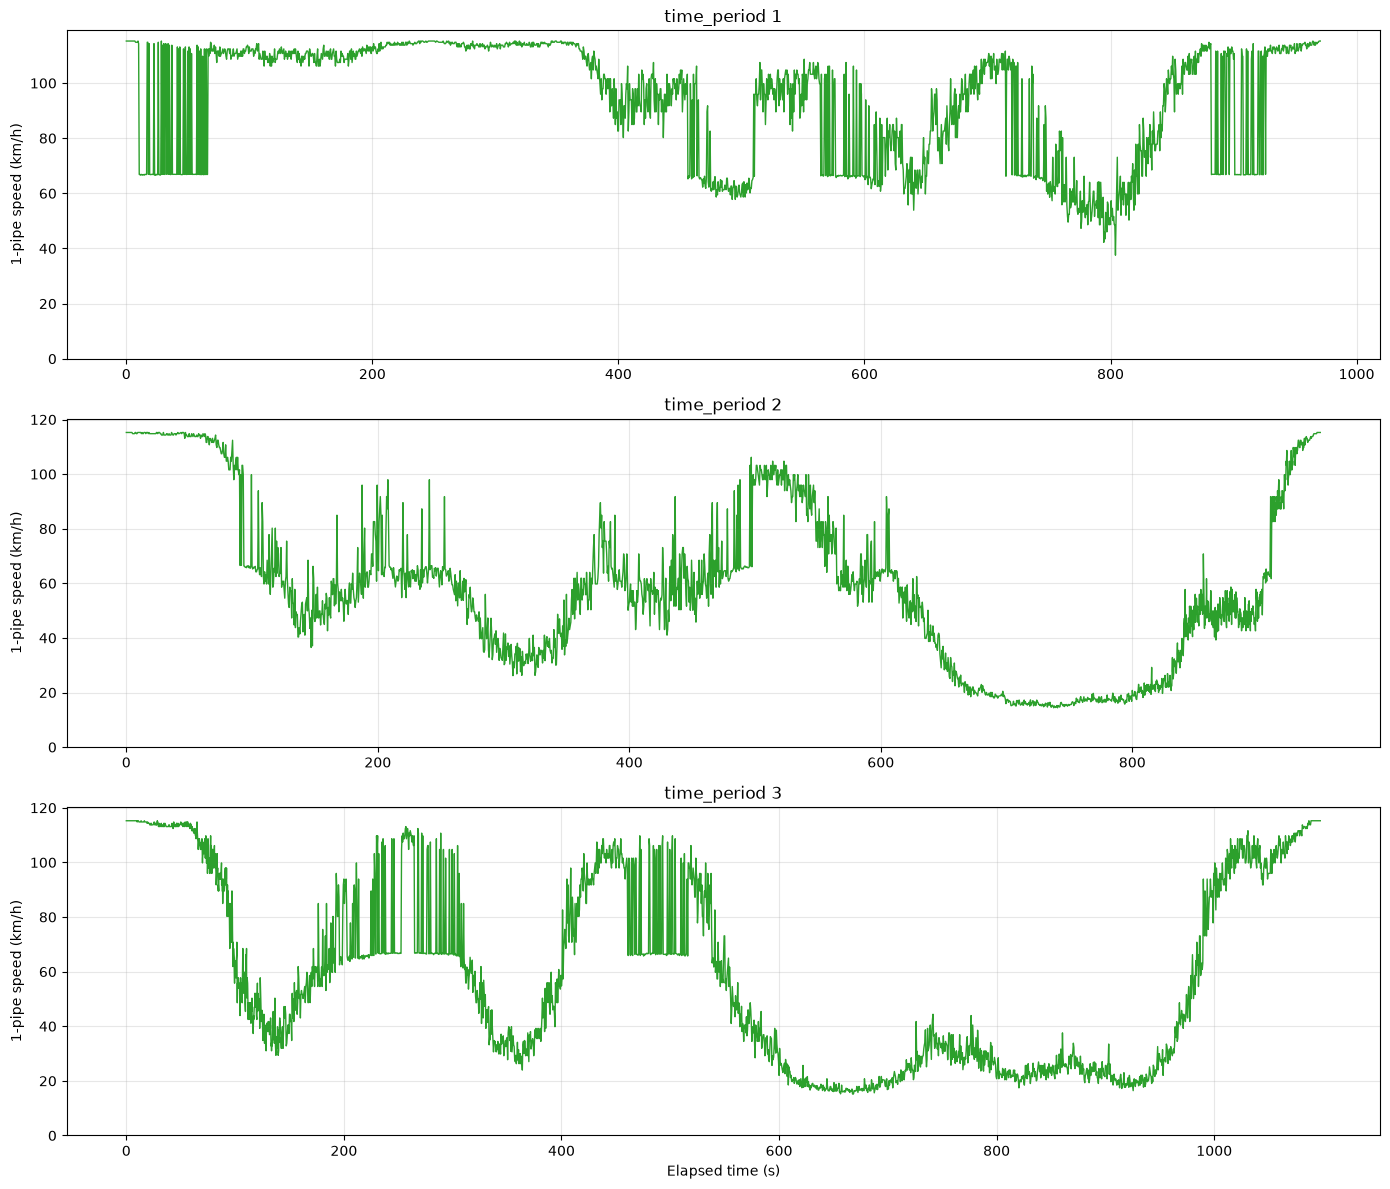

In [53]:
plot_1pipe_timeseries(df_1pipe_filtereddata)

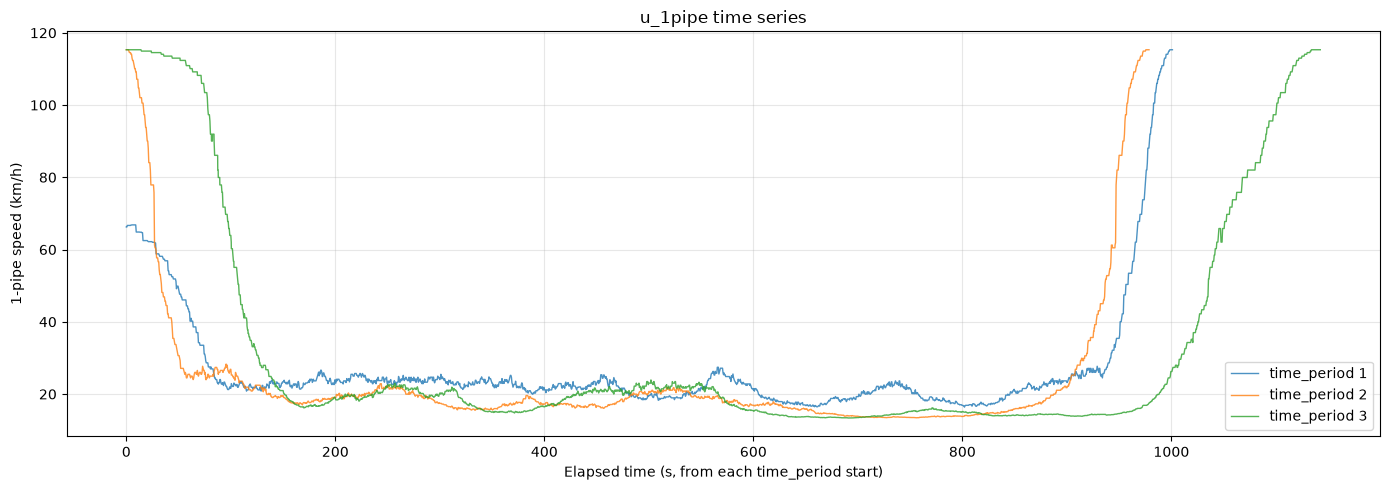

In [68]:
plot_timeseries_overlay(df_1pipe_full_data, 'u_1pipe', '1-pipe speed (km/h)')

In [55]:
u = df_1pipe_filtereddata['u_1pipe']
print(f"最大値: {u.max():.3f}")
print(f"最小値: {u.min():.3f}")
print(f"中央値: {u.median():.3f}")
print(f"最頻値: {u.mode().tolist()}")

最大値: 115.254
最小値: 14.404
中央値: 66.214
最頻値: [113.75042216165394]


In [56]:
u = df_1pipe_full_data['u_1pipe']
print(f"最大値: {u.max():.3f}")
print(f"最小値: {u.min():.3f}")
print(f"中央値: {u.median():.3f}")
print(f"最頻値: {u.mode().tolist()}")

最大値: 115.309
最小値: 13.348
中央値: 20.389
最頻値: [115.30921072406629]


### 最小道路占有　p*

In [113]:
def compute_min_road_share(df_1pipe, car_params, truck_params):
    """
    論文Eq(4)：最小道路占有 pi* = rho_i / ui^-1(u*) を計算する。

    ui^-1は「クラス自身の名目速度関数」の逆関数（_eq7_residual内のu1_inv,
    u2_invと同じ呼び出し。a2・b1によるスケーリングはここでは使わない）。

    df_1pipe: compute_1pipe_speed_for_snapshots の返り値
              （rho1, rho2, u_1pipe列を含む）
    car_params: C-Cの名目速度関数パラメータ
    truck_params: T-Tの名目速度関数パラメータ
    """
    df = df_1pipe.copy()

    # u*におけるクラス1・クラス2それぞれの"密度" u_i^-1(u*)
    u1_inv = logistic_density_speed(
        df['u_1pipe'], car_params['ub'], car_params['uf'], car_params['rhoc'],
        car_params['theta1'], car_params['theta2']
    )
    u2_inv = underwood_density_speed(df['u_1pipe'], truck_params['uf'], truck_params['rhoc'])

    df['p1_star'] = df['rho1'] / u1_inv
    df['p2_star'] = df['rho2'] / u2_inv

    n_valid = df[['p1_star', 'p2_star']].notna().all(axis=1).sum()
    print(f"最小道路占有を計算: {len(df):,}スナップショット中、{n_valid:,}件で計算完了")

    return df

In [114]:
#実行
df_pstar_full=compute_min_road_share(df_1pipe_full_data, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
df_pstar_filtered=compute_min_road_share(df_1pipe_filtereddata, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
df_pstar_full.head()
u = df_pstar_full['p2_star']
print(f"最大値: {u.max():.3f}")
print(f"最小値: {u.min():.3f}")
print(f"中央値: {u.median():.3f}")
print(f"最頻値: {u.mode().tolist()}")

最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
最小道路占有を計算: 6,561スナップショット中、6,561件で計算完了
最大値: 1.352
最小値: 0.000
中央値: 0.101
最頻値: [0.0]


In [115]:
single_class = df_pstar_full[(df_pstar_full['rho1'] == 0) | (df_pstar_full['rho2'] == 0)]
present_p = single_class['p1_star'].where(single_class['rho1'] > 0, single_class['p2_star'])
print(f"単独クラス行数: {len(single_class)}")
print(f"存在する方のp*: min={present_p.min():.6f}, max={present_p.max():.6f}")
print(f"1.0からのズレの最大値: {(present_p - 1.0).abs().max():.2e}")

単独クラス行数: 1038
存在する方のp*: min=1.000000, max=1.000000
1.0からのズレの最大値: 4.56e-14


In [116]:
df_pstar_full[['p1_star', 'p2_star']].describe()

v_Class,p1_star,p2_star
count,6970.000000,6970.000000
mean,0.895166,0.107582
std,0.095994,0.122956
min,0.000000,0.000000
25%,0.871991,0.061062
50%,0.899381,0.101475
75%,0.937783,0.126376
max,1.000000,1.352498


In [117]:
test_points = pd.DataFrame({
    'rho1': [0.0, 20.0, 20.0, 50.0, 70.0],
    'rho2': [2.0, 0.0, 2.0, 4.0, 6.0],
})

def _solve_row(row):
    try:
        return solve_1pipe_speed(row['rho1'], row['rho2'],
                                   results_cc_strong_constraint, results_tt_strong_constraint,
                                   results_a2['scaling_param'], results_b1['scaling_param'])
    except ValueError:
        return np.nan

test_points['u_1pipe'] = test_points.apply(_solve_row, axis=1)

test_pstar = compute_min_road_share(test_points, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
test_pstar['p_sum'] = test_pstar['p1_star'] + test_pstar['p2_star']

print(test_pstar[['rho1', 'rho2', 'u_1pipe', 'p1_star', 'p2_star', 'p_sum']].to_string(index=False))

最小道路占有を計算: 5スナップショット中、5件で計算完了
 rho1  rho2   u_1pipe  p1_star  p2_star    p_sum
  0.0   2.0 61.471661 0.000000 1.000000 1.000000
 20.0   0.0 72.256432 1.000000 0.000000 1.000000
 20.0   2.0 50.000646 0.724057 0.343073 1.067129
 50.0   4.0 16.999164 0.839805 0.154834 0.994640
 70.0   6.0 13.439161 0.811806 0.198733 1.010539


### 協力余剰sの計算

In [118]:
def compute_cooperation_surplus(df_pstar):
    """
    論文Definition 1：協力余剰 s := 1 - p1* - p2* を計算する。

    df_pstar: compute_min_road_share の返り値（p1_star, p2_star列を含む）
    """
    df = df_pstar.copy()
    df['s'] = 1.0 - df['p1_star'] - df['p2_star']

    n_valid = df['s'].notna().sum()
    n_positive = (df['s'] > 0).sum()
    print(f"協力余剰sを計算: {len(df):,}スナップショット中、{n_valid:,}件で計算完了"
          f"（うちs>0: {n_positive:,}件）")

    return df

協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 5,214件）


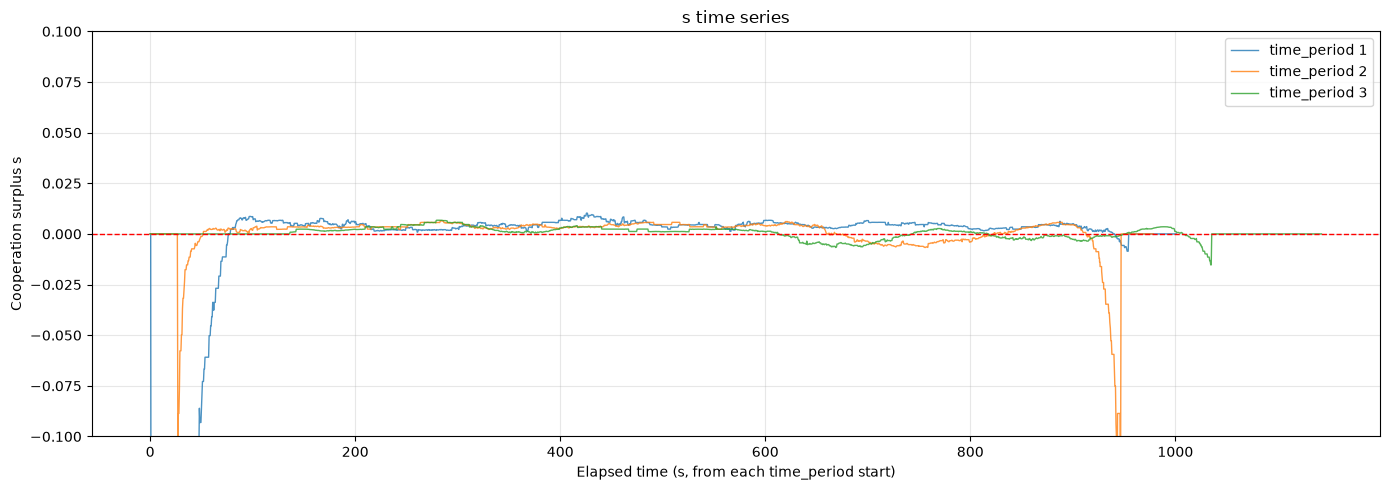

In [131]:
df_coops = compute_cooperation_surplus(df_pstar_full)
plot_timeseries_overlay(df_coops, 's', 'Cooperation surplus s', hline=0, ylim=(-0.10, 0.10))

協力余剰sを計算: 6,561スナップショット中、6,561件で計算完了（うちs>0: 1,689件）


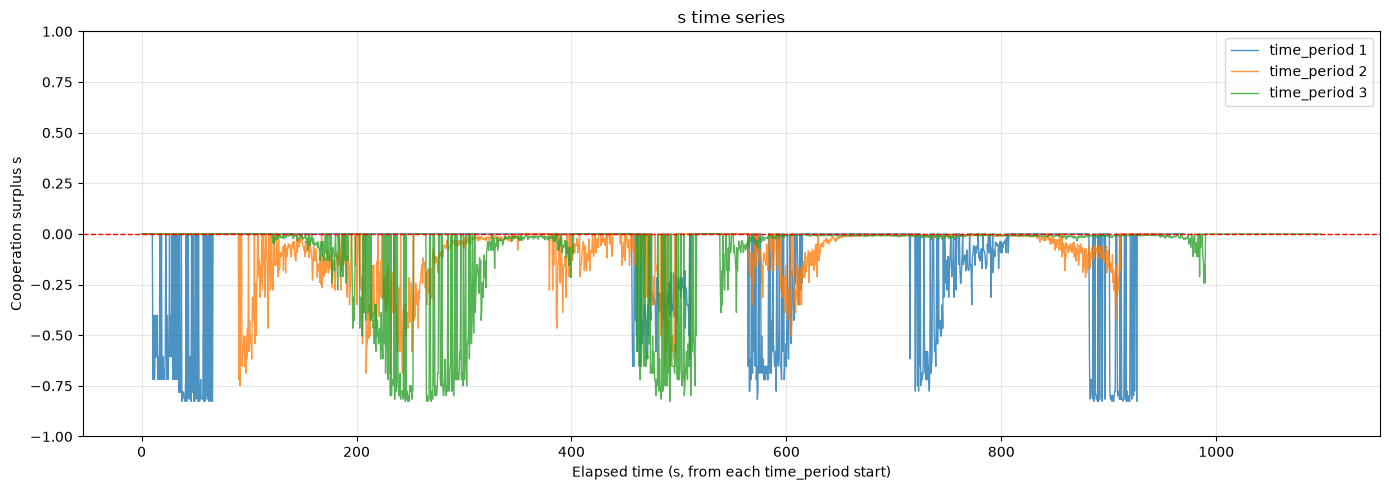

In [130]:
df_coops = compute_cooperation_surplus(df_pstar_filtered)
plot_timeseries_overlay(df_coops, 's', 'Cooperation surplus s', hline=0, ylim=(-1, 1))

In [121]:
def plot_cooperation_surplus_heatmap(df_s, bin_width1=1.0, bin_width2=1.0,
                                       max_rho1=None, max_rho2=None, min_count=3):
    """
    協力余剰sのヒートマップを、km単位版とmile単位版(論文の単位)を横並びで表示する。
    ビン分割の方式はplot_1pipe_speed_heatmapと同じ(mile版は独立に再ビン分割)。
    カラーマップは論文Fig.12に合わせてviridis、0を起点とした連続カラーにしている。
    """
    df = df_s.dropna(subset=['s']).copy()

    if max_rho1 is None:
        max_rho1 = df['rho1'].max()
    if max_rho2 is None:
        max_rho2 = df['rho2'].max()

    # --- km版 ---
    bins1_km, bins2_km, heat_s_km = _bin_and_aggregate_1pipe(
        df, 'rho1', 'rho2', bin_width1, bin_width2, max_rho1, max_rho2, min_count,
        value_col='s'
    )

    # --- mile版：rho1, rho2をmileに変換してから、mile換算のビン幅で独立に再分割 ---
    df['rho1_mile'] = df['rho1'] * KM_TO_MILE
    df['rho2_mile'] = df['rho2'] * KM_TO_MILE
    bin_width1_mile = bin_width1 * KM_TO_MILE
    bin_width2_mile = bin_width2 * KM_TO_MILE
    max_rho1_mile = max_rho1 * KM_TO_MILE
    max_rho2_mile = max_rho2 * KM_TO_MILE

    bins1_mile, bins2_mile, heat_s_mile = _bin_and_aggregate_1pipe(
        df, 'rho1_mile', 'rho2_mile', bin_width1_mile, bin_width2_mile,
        max_rho1_mile, max_rho2_mile, min_count, value_col='s'
    )

    # km版・mile版で共通の色スケール(0起点、絶対値最大に合わせる)
    vmax = np.nanmax(np.concatenate([heat_s_km.values.ravel(), heat_s_mile.values.ravel()]))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    mesh0 = axes[0].pcolormesh(bins1_km, bins2_km, heat_s_km.values, cmap='viridis', vmin=0, vmax=vmax, shading='flat')
    fig.colorbar(mesh0, ax=axes[0], label='Cooperation surplus s')
    axes[0].set_xlabel('Density class 1 - Car (veh/km)')
    axes[0].set_ylabel('Density class 2 - Truck (veh/km)')
    axes[0].set_title('Cooperation Surplus Heatmap (km)')

    mesh1 = axes[1].pcolormesh(bins1_mile, bins2_mile, heat_s_mile.values, cmap='viridis', vmin=0, vmax=vmax, shading='flat')
    fig.colorbar(mesh1, ax=axes[1], label='Cooperation surplus s')
    axes[1].set_xlabel('Density class 1 - Car (veh/mile)')
    axes[1].set_ylabel('Density class 2 - Truck (veh/mile)')
    axes[1].set_title('Cooperation Surplus Heatmap (mile, paper units)')

    plt.tight_layout()
    plt.show()

    return heat_s_km, heat_s_mile

In [122]:
# 該当ビンの件数を確認(minのcountsを見る、heatではなく)
# _bin_and_aggregate_1pipe内のcountsに相当する部分を、同じ条件で出し直す

# もしくは、該当する密度範囲の生データを直接見る
mask = (df_coops['rho2'] >= 0.599) & (df_coops['rho2'] <= 2.1) & \
       (df_coops['rho1'] >= 65.1) & (df_coops['rho1'] <= 66.6)
print(df_coops[mask][['rho1', 'rho2', 'u_1pipe', 'p1_star', 'p2_star', 's']])

Empty DataFrame
Columns: [rho1, rho2, u_1pipe, p1_star, p2_star, s]
Index: []


In [128]:
# 該当ビンの件数を確認(minのcountsを見る、heatではなく)
# _bin_and_aggregate_1pipe内のcountsに相当する部分を、同じ条件で出し直す

# もしくは、該当する密度範囲の生データを直接見る
mask = (df_s_paper['rho2'] >= 0.599) & (df_s_paper['rho2'] <= 2.1) & \
       (df_s_paper['rho1'] >= 65.1) & (df_s_paper['rho1'] <= 66.6)
print(df_s_paper[mask][['rho1', 'rho2', 'u_1pipe', 'p1_star', 'p2_star', 's']])

v_Class       rho1      rho2    u_1pipe   p1_star   p2_star         s
6300     65.344270  1.832082  20.531943  0.945301  0.058644 -0.003945
6312     65.954964  1.832082  20.315666  0.945780  0.058133 -0.003913
6313     65.954964  1.832082  20.315666  0.945780  0.058133 -0.003913
6314     66.565658  1.832082  20.105325  0.946248  0.057639 -0.003887
6315     65.344270  1.832082  20.531943  0.945301  0.058644 -0.003945
6316     65.344270  1.832082  20.531943  0.945301  0.058644 -0.003945
6317     65.954964  1.832082  20.315666  0.945780  0.058133 -0.003913
6318     66.565658  1.832082  20.105325  0.946248  0.057639 -0.003887
6319     66.565658  1.832082  20.105325  0.946248  0.057639 -0.003887


1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 395件）


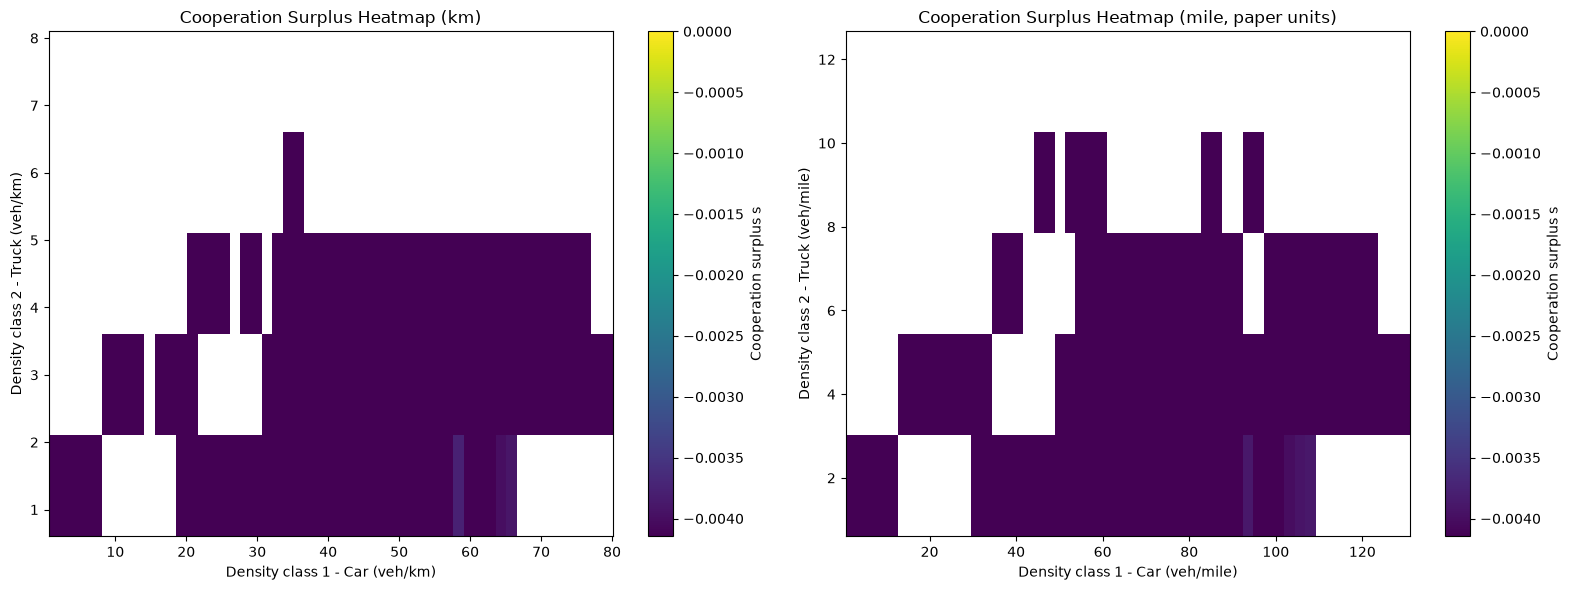

(              (0.599, 2.1]  (2.1, 3.6]  (3.6, 5.1]  (5.1, 6.6]  (6.6, 8.1]  \
 (0.599, 2.1]     -0.590841   -0.626216   -0.608556   -0.582373   -0.587063   
 (2.1, 3.6]             NaN         NaN         NaN         NaN         NaN   
 (3.6, 5.1]             NaN         NaN         NaN         NaN         NaN   
 (5.1, 6.6]             NaN         NaN         NaN         NaN         NaN   
 (6.6, 8.1]             NaN         NaN         NaN         NaN         NaN   
 
               (8.1, 9.6]  (9.6, 11.1]  (11.1, 12.6]  (12.6, 14.1]  \
 (0.599, 2.1]         NaN          NaN           NaN           NaN   
 (2.1, 3.6]     -0.486216     -0.46797     -0.428982      -0.35132   
 (3.6, 5.1]           NaN          NaN           NaN           NaN   
 (5.1, 6.6]           NaN          NaN           NaN           NaN   
 (6.6, 8.1]           NaN          NaN           NaN           NaN   
 
               (14.1, 15.6]  ...  (65.1, 66.6]  (66.6, 68.1]  (68.1, 69.6]  \
 (0.599, 2.1]           

In [124]:
df_1pipe_paper = compute_1pipe_speed_for_snapshots(
    df_macro_data,
    car_params=results_cc_paper_km,
    truck_params=results_tt_paper_km,
    a2=results_a2_paper_km['scaling_param'],
    b1=results_b1_paper_km['scaling_param'],
)
df_pstar_paper = compute_min_road_share(df_1pipe_paper, car_params=results_cc_paper_km, truck_params=results_tt_paper_km)
df_s_paper = compute_cooperation_surplus(df_pstar_paper)
plot_cooperation_surplus_heatmap(df_s_paper, bin_width1=1.5, bin_width2=1.5, max_rho1=80, max_rho2=7, min_count=3)

最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 5,214件）


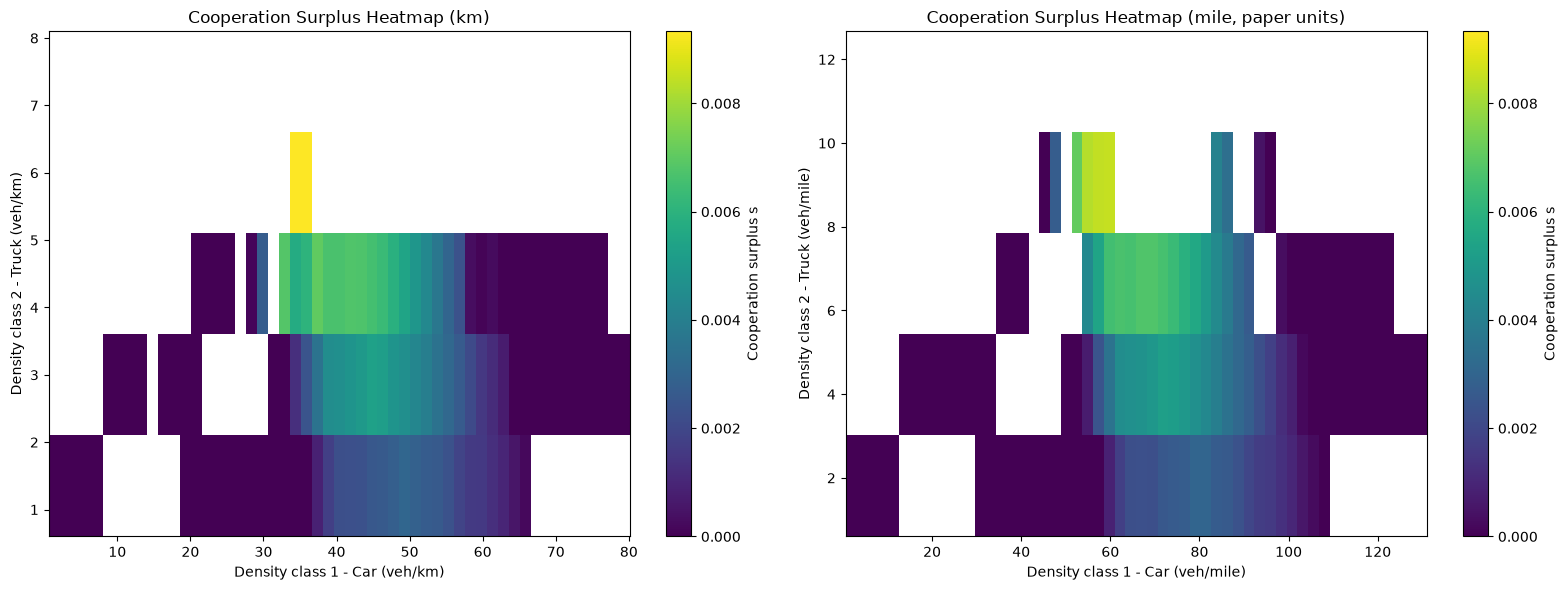

(              (0.599, 2.1]  (2.1, 3.6]  (3.6, 5.1]  (5.1, 6.6]  (6.6, 8.1]  \
 (0.599, 2.1]     -0.352507   -0.349153   -0.320358   -0.289989   -0.283736   
 (2.1, 3.6]             NaN         NaN         NaN         NaN         NaN   
 (3.6, 5.1]             NaN         NaN         NaN         NaN         NaN   
 (5.1, 6.6]             NaN         NaN         NaN         NaN         NaN   
 (6.6, 8.1]             NaN         NaN         NaN         NaN         NaN   
 
               (8.1, 9.6]  (9.6, 11.1]  (11.1, 12.6]  (12.6, 14.1]  \
 (0.599, 2.1]         NaN          NaN           NaN           NaN   
 (2.1, 3.6]     -0.216361     -0.19598     -0.168163     -0.123273   
 (3.6, 5.1]           NaN          NaN           NaN           NaN   
 (5.1, 6.6]           NaN          NaN           NaN           NaN   
 (6.6, 8.1]           NaN          NaN           NaN           NaN   
 
               (14.1, 15.6]  ...  (65.1, 66.6]  (66.6, 68.1]  (68.1, 69.6]  \
 (0.599, 2.1]           

In [ ]:
df_pstar_full = compute_min_road_share(df_1pipe_full_data, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
df_s_full = compute_cooperation_surplus(df_pstar_full)
plot_cooperation_surplus_heatmap(df_s_full, bin_width1=1.5, bin_width2=1.5, max_rho1=80, max_rho2=7, min_count=3)

#ただ、超過量が0.04ととても小さい(=閾値0.401に対してほぼギリギリ)ことを考えると、
# この「自前パラメータだと時々正になる」という現象自体、b1の推定誤差というノイズの範囲でたまたま境界をまたいでいるだけ、と捉えるのが妥当だと思います。
# 「本質的にs>0が成立しやすい」という強い主張ではなく、「たまたまわずかに超えた」というくらいの弱い現象です。

最小道路占有を計算: 6,561スナップショット中、6,561件で計算完了
協力余剰sを計算: 6,561スナップショット中、6,561件で計算完了（うちs>0: 1,689件）


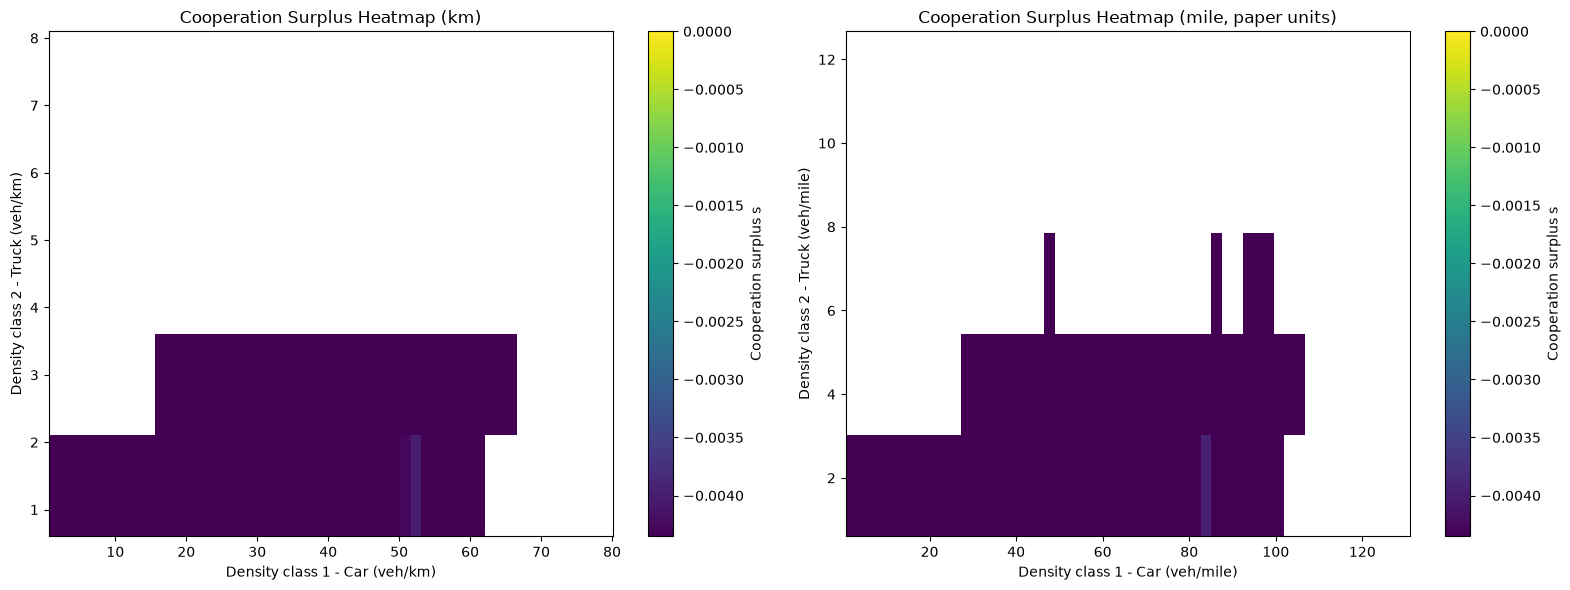

(              (0.599, 2.1]  (2.1, 3.6]  (3.6, 5.1]  (5.1, 6.6]  (6.6, 8.1]  \
 (0.599, 2.1]     -0.552578   -0.760758    -0.82626   -0.807682   -0.764924   
 (2.1, 3.6]             NaN         NaN         NaN         NaN         NaN   
 (3.6, 5.1]             NaN         NaN         NaN         NaN         NaN   
 (5.1, 6.6]             NaN         NaN         NaN         NaN         NaN   
 (6.6, 8.1]             NaN         NaN         NaN         NaN         NaN   
 
               (8.1, 9.6]  (9.6, 11.1]  (11.1, 12.6]  (12.6, 14.1]  \
 (0.599, 2.1]   -0.702557    -0.633001      -0.55277      -0.46057   
 (2.1, 3.6]           NaN          NaN           NaN           NaN   
 (3.6, 5.1]           NaN          NaN           NaN           NaN   
 (5.1, 6.6]           NaN          NaN           NaN           NaN   
 (6.6, 8.1]           NaN          NaN           NaN           NaN   
 
               (14.1, 15.6]  ...  (65.1, 66.6]  (66.6, 68.1]  (68.1, 69.6]  \
 (0.599, 2.1]     -0.366

In [127]:
df_pstar_filtered = compute_min_road_share(df_1pipe_filtereddata, car_params=results_cc_strong_constraint, truck_params=results_tt_strong_constraint)
df_s_filtered = compute_cooperation_surplus(df_pstar_filtered)
plot_cooperation_surplus_heatmap(df_s_filtered, bin_width1=1.5, bin_width2=1.5, max_rho1=80, max_rho2=7, min_count=3)

In [90]:
df_1pipe = compute_1pipe_speed_for_snapshots(df_macro_data, car_params=results_cc_paper_km, truck_params=results_tt_paper_km,
                                             a2=results_a2_paper_km['scaling_param'], b1=results_b1_paper_km['scaling_param'])
df_pstar = compute_min_road_share(df_1pipe, car_params=results_cc_paper_km, truck_params=results_tt_paper_km)  # 同じparams

1-pipe速度を計算: 6,561スナップショット中、6,561件で解を取得
最小道路占有を計算: 6,561スナップショット中、6,561件で計算完了


In [ ]:
# def _eq7_residual(u, rho1, rho2, car_params, truck_params, a2, b1, scaling='inverted'):
#     rho_tot = rho1 + rho2
#     u1_inv = logistic_density_speed(
#         u, car_params['ub'], car_params['uf'], car_params['rhoc'],
#         car_params['theta1'], car_params['theta2']
#     )
#     u2_inv = underwood_density_speed(u, truck_params['uf'], truck_params['rhoc'])

#     if scaling == 'printed':      # 論文Eq.7の記載どおり: rho_j/a_j, rho_j/b_j
#         c_ct, c_tc = 1.0 / a2, 1.0 / b1
#     elif scaling == 'inverted':   # a2,b1を逆に効かせる: rho_j*a_j, rho_j*b_j (論文Fig.11/12を再現)
#         c_ct, c_tc = a2, b1
#     else:
#         raise ValueError("scaling は 'printed' か 'inverted' を指定してください")

#     term1 = (rho1 / u1_inv) * (rho1 + rho2 * c_ct)   # 車(クラス1)の項
#     term2 = (rho2 / u2_inv) * (rho1 * c_tc + rho2)   # トラック(クラス2)の項
#     return (term1 + term2) / rho_tot - 1.0


# def solve_1pipe_speed(rho1, rho2, car_params, truck_params, a2, b1,
#                       u_lower=None, u_upper=None, margin=1e-3, scaling='inverted'):
#     if rho1 + rho2 <= 0:
#         return np.nan

#     if u_lower is None or u_upper is None:
#         uppers = []
#         if rho1 > 0:
#             # 車のufは到達できない漸近値なので、密度0での実際の最高速度f(0)を上限にする
#             car_speed_at_zero = logistic_speed_density(
#                 0.0, car_params['ub'], car_params['uf'], car_params['rhoc'],
#                 car_params['theta1'], car_params['theta2']
#             )
#             uppers.append(car_speed_at_zero - margin)
#         if rho2 > 0:
#             uppers.append(truck_params['uf'] - margin)  # Underwoodはg(0)=ufなのでそのままでOK
#         if u_lower is None:
#             u_lower = margin   # 下限は全クラス共通で0付近から探索
#         if u_upper is None:
#             u_upper = min(uppers)

#     f = lambda u: _eq7_residual(u, rho1, rho2, car_params, truck_params, a2, b1, scaling)
#     return brentq(f, u_lower, u_upper)


# def compute_1pipe_speed_for_snapshots(df_macro, car_params, truck_params, a2, b1,
#                                       car_class=2, truck_class=3, scaling='inverted'):
#     pivot = df_macro.pivot_table(
#         index=['time_period', 'Global_Time'],
#         columns='v_Class',
#         values='density_veh_km'
#     ).rename(columns={car_class: 'rho1', truck_class: 'rho2'})

#     pivot[['rho1', 'rho2']] = pivot[['rho1', 'rho2']].fillna(0.0)
#     pivot = pivot.reset_index()

#     def _solve_row(row):
#         try:
#             return solve_1pipe_speed(row['rho1'], row['rho2'], car_params, truck_params,
#                                      a2, b1, scaling=scaling)
#         except ValueError:
#             return np.nan

#     pivot['rho_tot'] = pivot['rho1'] + pivot['rho2']
#     pivot['u_1pipe'] = pivot.apply(_solve_row, axis=1)
#     print(f"1-pipe速度を計算: {len(pivot):,}スナップショット中、"
#           f"{pivot['u_1pipe'].notna().sum():,}件で解を取得")
#     return pivot


# def compute_surplus_pipeline(df_macro, car_params, truck_params, a2, b1,
#                              scaling='inverted', warmup_s=0):
#     """
#     マクロ密度スナップショット -> u* -> p1*,p2* -> s を、同じパラメータで一括計算する。
#     u*とp*に別々のパラメータを渡してしまうミスを防ぐため、パラメータは1回だけ受け取る。
#     warmup_s: 各time_periodの最初のwarmup_s秒(区間がまだ空の立ち上がり)を除外する。
#     """
#     df = compute_1pipe_speed_for_snapshots(df_macro, car_params, truck_params, a2, b1, scaling=scaling)

#     if warmup_s > 0:
#         elapsed = (df['Global_Time'] - df.groupby('time_period')['Global_Time'].transform('min')) / 1000
#         df = df[elapsed >= warmup_s].copy()
#         print(f"立ち上がり区間(各time_periodの最初の{warmup_s}秒)を除外: 残り{len(df):,}スナップショット")

#     df = compute_min_road_share(df, car_params, truck_params)
#     df = compute_cooperation_surplus(df)
#     return df

In [ ]:
# df_macro_data = compute_macroscopic_data(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

# # 論文パラメータで確認
# df_s_paper = compute_surplus_pipeline(
#     df_macro_data, results_cc_paper_km, results_tt_paper_km,
#     results_a2_paper_km['scaling_param'], results_b1_paper_km['scaling_param'])

# # 手元の推定パラメータ
# df_s = compute_surplus_pipeline(
#     df_macro_data, results_cc_strong_constraint, results_tt_strong_constraint,
#     results_a2['scaling_param'], results_b1['scaling_param'])

# # 確認用: 車のみ/トラックのみの行ではs=0になるはず(1e-13程度)
# single = df_s[(df_s['rho1'] == 0) | (df_s['rho2'] == 0)]
# print(single['s'].abs().max())

区間長: 545.8 m, 車線数: 3

--マクロ密度・平均速度を計算--
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 6,327件）
1-pipe速度を計算: 6,970スナップショット中、6,970件で解を取得
最小道路占有を計算: 6,970スナップショット中、6,970件で計算完了
協力余剰sを計算: 6,970スナップショット中、6,970件で計算完了（うちs>0: 6,536件）
4.5630166312093934e-14


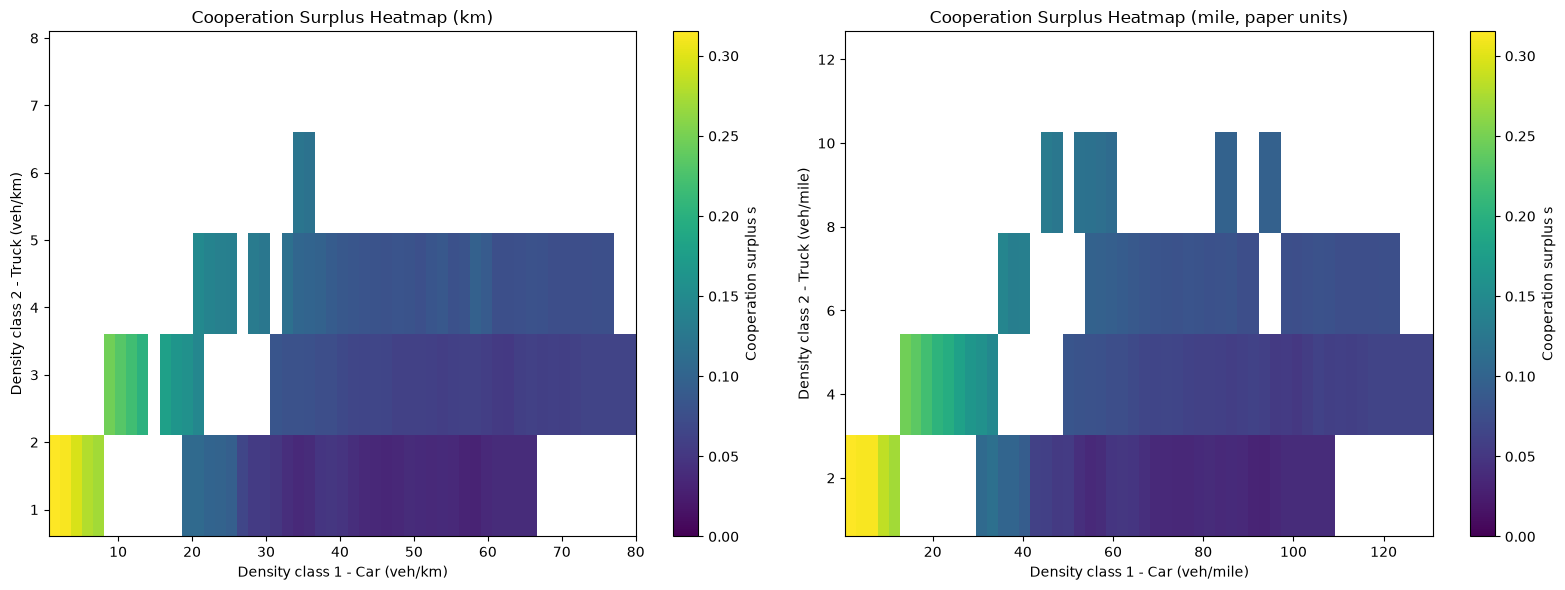

(              (0.599, 2.1]  (2.1, 3.6]  (3.6, 5.1]  (5.1, 6.6]  (6.6, 8.1]  \
 (0.599, 2.1]      0.315306     0.31251    0.295798    0.279154    0.271875   
 (2.1, 3.6]             NaN         NaN         NaN         NaN         NaN   
 (3.6, 5.1]             NaN         NaN         NaN         NaN         NaN   
 (5.1, 6.6]             NaN         NaN         NaN         NaN         NaN   
 (6.6, 8.1]             NaN         NaN         NaN         NaN         NaN   
 
               (8.1, 9.6]  (9.6, 11.1]  (11.1, 12.6]  (12.6, 14.1]  \
 (0.599, 2.1]         NaN          NaN           NaN           NaN   
 (2.1, 3.6]      0.246964     0.232526      0.218319      0.201136   
 (3.6, 5.1]           NaN          NaN           NaN           NaN   
 (5.1, 6.6]           NaN          NaN           NaN           NaN   
 (6.6, 8.1]           NaN          NaN           NaN           NaN   
 
               (14.1, 15.6]  ...  (65.1, 66.6]  (66.6, 68.1]  (68.1, 69.6]  \
 (0.599, 2.1]           

In [ ]:

# plot_cooperation_surplus_heatmap(df_s, bin_width1=1.5, bin_width2=1.5, max_rho1=80, max_rho2=7, min_count=3)

### テスト

#### 1-pipe速度
論文と全く同じパラメータで推定をし、同じ結果が得られるか


In [127]:
def logistic_density_speed(v, ub, uf, rhoc, theta1, theta2):
    """
    逆関数: 速度 v から 密度 rho を予測
    rho = rhoc + theta1 * ln( ((uf - ub) / (v - ub))^(1/theta2) - 1 )
    """
    # 数学的に定義できない領域（v <= ub または v >= uf）に対する数値的クリップ
    #0で割り算することを防ぐ
    eps = 1e-4
    #v_clipped = np.clip(v, ub + eps, uf - eps)

    # 累乗項の計算
    ratio = (uf - ub) / (v - ub)
    inner_term = (ratio ** (1.0 / theta2)) - 1.0

    # 対数の中身が 0 以下にならないようにクリップ
    #inner_term = np.clip(inner_term, 1e-10, None)

    return rhoc + theta1 * np.log(inner_term)

def underwood_density_speed(v, uf, rhoc):
    """
    逆関数: 速度 v から 密度 rho を予測
    g(rho) = uf * exp(-rho/rhoc) を rho について解くと、
    rho = rhoc * ln(uf / v)
    """
    # 数学的に定義できない領域（v <= 0 または v >= uf）に対する数値的クリップ
    eps = 1e-6
    #v_clipped = np.clip(v, eps, uf - eps)

    return rhoc * np.log(uf / v)


     rho_1(vpm)  rho_2(vpm)  u^*(mph)  1pipe_cal
0           2.5         2.5      40.0  40.653491
1           5.0         2.5      40.0  40.799681
2           7.5         2.5      38.0  40.822834
3          10.0         2.5      38.0  40.786360
4          12.5         2.5      37.0  40.709656
5          15.0         2.5       NaN        NaN
6          17.5         2.5       NaN        NaN
7          20.0         2.5       NaN        NaN
8          22.5         2.5       NaN        NaN
9          25.0         2.5       NaN        NaN
10         27.5         2.5       NaN        NaN
11         30.0         2.5       NaN        NaN
12         32.5         2.5      36.0  38.346956
13         35.0         2.5      36.0  37.633477
14         37.5         2.5       NaN        NaN
15         40.0         2.5      34.5  35.743201
16         42.5         2.5      33.0  34.585652
17         45.0         2.5      32.5  33.327800
18         47.5         2.5      31.0  32.010433
19         50.0     

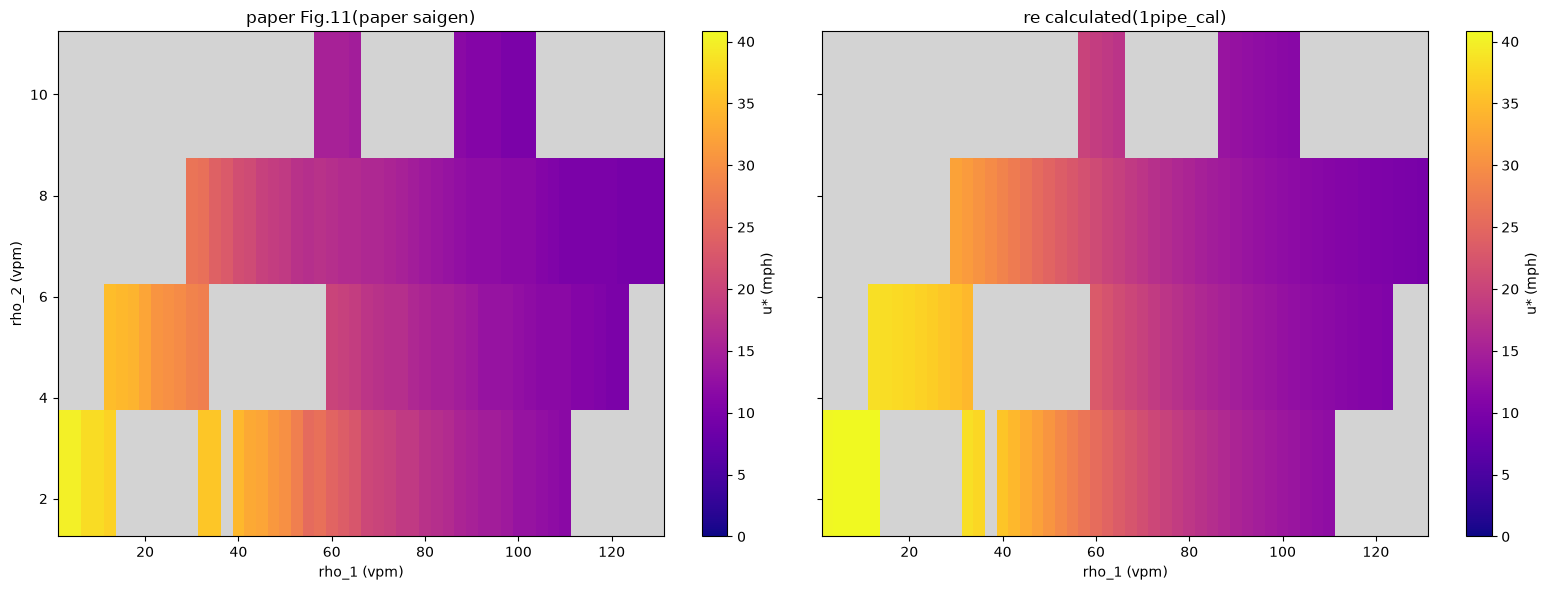

In [159]:
#論文から読みとれる密度のペアと1-pipe速度の組み合わせを確認する
#one_pipe_test = pd.read_csv(r"C:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\data\one_pipe_test.csv")
one_pipe_test = pd.read_csv(r"C:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\data\1-pipe_test.csv")

def parse_rgb(s):
    return tuple(int(x) for x in s.strip('()').split(','))

#速度と色の対応からu^*をすべて計算させる　あくまで大体の値だけど…
mask = one_pipe_test['color'].notna()
one_pipe_test.loc[mask, 'u^*(mph)'] = one_pipe_test.loc[mask, 'color'].apply(lambda s: rgb_to_speed(parse_rgb(s)))

VPM_TO_VEHKM = 1 / KM_TO_MILE

# solve_1pipe_speedは、kmで計算するから一回kmに直す
def _solve_row(row):
    rho1_km = row['rho_1(vpm)'] * VPM_TO_VEHKM
    rho2_km = row['rho_2(vpm)'] * VPM_TO_VEHKM
    try:
        return solve_1pipe_speed(
            rho1_km, rho2_km,
            results_cc_paper_km, results_tt_paper_km,#論文と同じパラメータを使用して計算
            results_a2_paper_km['scaling_param'], results_b1_paper_km['scaling_param']
        )
    except ValueError:
        return np.nan

one_pipe_test['1pipe_cal'] = one_pipe_test.apply(_solve_row, axis=1) / KM_TO_MILE#kmにしたものをもう一回mileに戻す
#one_pipe_test.head()
one_pipe_test['1pipe_cal'] = one_pipe_test['1pipe_cal'].where(one_pipe_test['u^*(mph)'].notna())
#print(one_pipe_test[['rho_1(vpm)', 'rho_2(vpm)', 'u^*(mph)', '1pipe_cal']].head(20))
print(one_pipe_test[['rho_1(vpm)', 'rho_2(vpm)', 'u^*(mph)', '1pipe_cal']].to_string())

pivot_paper = one_pipe_test.pivot(index='rho_2(vpm)', columns='rho_1(vpm)', values='u^*(mph)')
pivot_cal = one_pipe_test.pivot(index='rho_2(vpm)', columns='rho_1(vpm)', values='1pipe_cal')

vmax = np.nanmax([pivot_paper.values, pivot_cal.values])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, pivot, title in [
    (axes[0], pivot_paper, 'paper Fig.11(paper saigen)'),
    (axes[1], pivot_cal, 're calculated(1pipe_cal)'),
]:
    ax.set_facecolor('lightgray')  # データがないセルはグレーに
    mesh = ax.pcolormesh(pivot.columns, pivot.index, pivot.values, cmap='plasma',
                          vmin=0, vmax=vmax, shading='nearest')
    fig.colorbar(mesh, ax=ax, label='u* (mph)')
    ax.set_title(title)
    ax.set_xlabel('rho_1 (vpm)')

axes[0].set_ylabel('rho_2 (vpm)')
plt.tight_layout()
plt.show()

In [161]:
df_test = pd.read_csv(r"C:\Users\AMhetero\Desktop\1-pipe_test.csv")

def parse_rgb(s):
    return tuple(int(x) for x in s.strip('()').split(','))

color_mask = df_test['color'].notna()
df_test.loc[color_mask, 'u^*(mph)'] = df_test.loc[color_mask, 'color'].apply(
    lambda s: rgb_to_speed(parse_rgb(s))
)

# CSVのrho値は2.5vpm刻みのビンを表しているとみなし、+2.25vpmずらした値を
# 計算の入力に使う(実データでMAEが最小になったoffset)
OFFSET_VPM = 2.25
VPM_TO_VEHKM = 1 / KM_TO_MILE

df_test['rho1_km'] = (df_test['rho_1(vpm)'] + OFFSET_VPM) * VPM_TO_VEHKM
df_test['rho2_km'] = (df_test['rho_2(vpm)'] + OFFSET_VPM) * VPM_TO_VEHKM

def _solve_row(row):
    try:
        return solve_1pipe_speed(row['rho1_km'], row['rho2_km'],
                                   results_cc_paper_km, results_tt_paper_km,
                                   0.4528, 2.5996)
    except ValueError:
        return np.nan

df_test['u_1pipe_kmh'] = df_test.apply(_solve_row, axis=1)
df_test['u_1pipe_mph'] = df_test['u_1pipe_kmh'] / KM_TO_MILE

compare = df_test[['rho_1(vpm)', 'rho_2(vpm)', 'u^*(mph)', 'u_1pipe_mph']].copy()
compare['diff_mph'] = compare['u_1pipe_mph'] - compare['u^*(mph)']

valid = compare.dropna(subset=['u^*(mph)'])
mae = valid['diff_mph'].abs().mean()
bias = valid['diff_mph'].mean()
print(f"比較できた行数: {len(valid)}, MAE: {mae:.3f}mph, bias: {bias:+.3f}mph")

比較できた行数: 123, MAE: 1.173mph, bias: +0.170mph


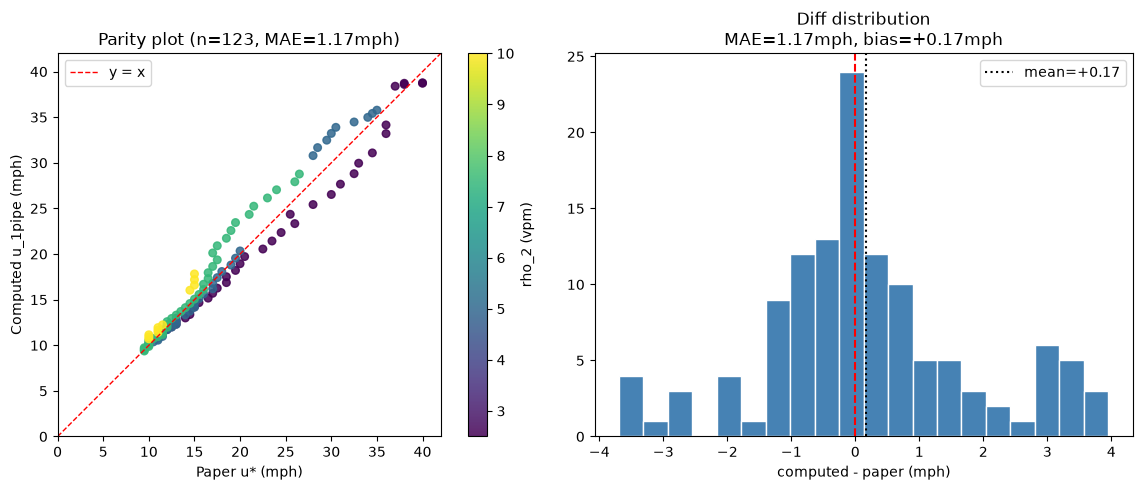

In [162]:
import matplotlib.pyplot as plt

valid = compare.dropna(subset=['u^*(mph)', 'u_1pipe_mph'])
mae = valid['diff_mph'].abs().mean()
bias = valid['diff_mph'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sc = ax.scatter(valid['u^*(mph)'], valid['u_1pipe_mph'], c=valid['rho_2(vpm)'],
                 cmap='viridis', s=30, alpha=0.85)
lims = [0, 42]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x')
ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
ax.set_xlabel('Paper u* (mph)')
ax.set_ylabel('Computed u_1pipe (mph)')
ax.set_title(f'Parity plot (n={len(valid)}, MAE={mae:.2f}mph)')
ax.legend()
fig.colorbar(sc, ax=ax, label='rho_2 (vpm)')

ax2 = axes[1]
ax2.hist(valid['diff_mph'], bins=20, color='steelblue', edgecolor='white')
ax2.axvline(0, color='red', linestyle='--')
ax2.axvline(bias, color='black', linestyle=':', label=f'mean={bias:+.2f}')
ax2.set_title(f'Diff distribution\nMAE={mae:.2f}mph, bias={bias:+.2f}mph')
ax2.set_xlabel('computed - paper (mph)')
ax2.legend()

plt.tight_layout()
plt.show()